# Fitting SAXS to cylinder form factor distributions

## Imports

In [2]:
# Imports:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import skewnorm, norm
from lmfit import Model, Parameters
from lmfit.model import save_modelresult, load_modelresult
import xarray as xr

## Functions

In [131]:
def skew_trimodal(D, mean1, scale1, shape1, weight1, mean2, scale2, shape2, weight2, mean3, scale3, shape3):
    # Ensure the weight is between 0 and 1
    if weight1 < 0 or weight1+weight2 > 1 or weight2<0:
        raise ValueError("Weight1 should be in the range [0, 1]")
    # Calculate the weight of the second normal distribution
    weight3 = 1.0 - weight1 - weight2
    # Evaluate the two distributions on the range of x values
    y1 = skewnorm.pdf(D, shape1, mean1, scale1)
    y2 = skewnorm.pdf(D, shape2, mean2, scale2)
    y3 = skewnorm.pdf(D, shape3, mean3, scale3)
    # Combine the distributions to create a bimodal distribution
    trimodal = weight1 * y1 + weight2 * y2 + weight3 * y3
    return trimodal

def compute_mixture_intensity_skewtrimodal(q_values, intensities, diameters, mean1, scale1, shape1, weight1, mean2, scale2, shape2, weigth2, mean3, scale3, shape3):
    mixture_intensity = np.zeros_like(q_values)
    for i, D in enumerate(diameters):
        weight = skew_trimodal(D, mean1, scale1, shape1, weight1, mean2, scale2, shape2, weigth2, mean3, scale3, shape3)
        mixture_intensity += weight * intensities[i]
    return mixture_intensity

# def trimodal_fit_function(fibrilsPath, q_vals, total_scale, avg_diam1, sigma1, shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3):
def trimodal_fit_function(q_vals, total_scale, avg_diam1, sigma1, shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3):
    # Generate list of fibril folders to use:
    folders = sorted(fibrilsPath.glob('dtot*'), key=lambda f: float(f.name.split('_')[0][6:]))
    
    # Extract I vs Q data and diameters from all folder names:
    intensities_list = []
    diameters = []
    for folder in folders:
        # Extracting the diameter from the folder name
        diameter = float(folder.name.split('_')[0][6:])
        diameters.append(diameter)
        
        filepath = folder.joinpath("flex_cylinder_num0_QI.txt")
        if filepath.exists():
            data = np.loadtxt(filepath)
            data_q_values, intensities = data[:, 0], data[:, 1]
            downsampled_intensities = np.interp(q_vals, data_q_values, intensities)
            downsampled_intensities[downsampled_intensities<0] = 1e-12
            intensities_list.append(downsampled_intensities)

    mixture_intensity = compute_mixture_intensity_skewtrimodal(q_vals, intensities_list, diameters, avg_diam1, sigma1, 
                                                               shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3)
    

    # Scale the simulated mixture intensity
    scaled_mixture_intensity = mixture_intensity * total_scale*1e-4

    return scaled_mixture_intensity

In [25]:
# fibrilsPath = pathlib.Path('/Users/andrew/local_data_analysis/local_rsoxs/data')
# fibril_paths = sorted(fibrilsPath.glob('dtot*'), key=lambda f: float(f.name.split('_')[0][6:]))
# [f.name for f in fibril_paths]

## Load data

In [3]:
saxsPath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/for_PM6_fibrils/solution_saxs')

In [4]:
saxs_arrs = {}

for f in sorted(saxsPath.glob('*')):
    # print('_'.join(f.name.split('_')[:2]))
    var_name = '_'.join(f.name.split('_')[:2])
    saxs_arrs[var_name] = np.loadtxt(f)

saxs_arrs.keys()

dict_keys(['PM6_CB', 'PM6_CF', 'PM6_CN', 'PM7_CB', 'PM7_CF', 'PM7_CN'])

In [13]:
# Load data into dict of numpy arrays
saxs_arrs = {}

for f in sorted(saxsPath.glob('*')):
    # print('_'.join(f.name.split('_')[:2]))
    var_name = '_'.join(f.name.split('_')[:2])
    saxs_arrs[var_name] = np.loadtxt(f)

# # Smooth saxs with gaussian filter:
sigma = 2  # In pixels

bad_CF_q_slices = [
    slice(0.0561, 0.0569),
    slice(0.0608, 0.0629)
]

# Put numpy arrays into DataArrays
# saxs_DAs = []
saxs_DS = xr.Dataset(attrs={'name':'PM6_Solution_SAXS'})
for var_name, arr in saxs_arrs.items():
    saxs_DA = xr.DataArray(data=arr[:,1], dims=['q'], coords={'q':arr[:,0], 'err':('q', arr[:,2])})
    if var_name == 'PM6_CF':
        # saxs_DA.loc[{'q':slice(0.0634, None)}].where(saxs_DA.sel(q=slice(0.0634, None))<0.00115)
        saxs_DA.loc[{'q':slice(0.0634, None)}] = saxs_DA.where(saxs_DA.sel(q=slice(0.0634, None))<0.00115)
        for bad_q_slice in bad_CF_q_slices:
            # saxs_DA.sel(q=bad_q_slice).data = np.full(saxs_DA.sel(q=bad_q_slice).data.shape, np.nan)
            saxs_DA.loc[{'q':bad_q_slice}] = np.nan

    saxs_DA = saxs_DA.interpolate_na(dim='q')
    saxs_DA.data = gaussian_filter1d(saxs_DA.data, sigma=sigma)

    
    saxs_DA = saxs_DA.where(saxs_DA>2e-4)
    
    saxs_DS[var_name] = saxs_DA  #.where(saxs_DA>2e-4)  #.interpolate_na(dim='q')
    # saxs_DS[var_name] = saxs_DA.where(saxs_DA>2e-4).interpolate_na(dim='q')
    # saxs_DS[var_name].data = gaussian_filter1d(saxs_DS[var_name].data, sigma)

saxs_DS


<xarray.Dataset>
Dimensions:  (q: 2113)
Coordinates:
  * q        (q) float64 0.002496 0.002675 0.002855 ... 4.45 4.454 4.458
    err      (q) float64 0.486 0.3328 0.2544 ... 2.857e-05 2.908e-05 2.955e-05
Data variables:
    PM6_CB   (q) float64 1.686 1.586 1.42 1.234 1.063 ... nan nan nan nan nan
    PM6_CF   (q) float64 0.4512 0.4257 0.3838 0.3369 0.2926 ... nan nan nan nan
    PM6_CN   (q) float64 1.212 1.175 1.109 1.029 0.9466 ... nan nan nan nan nan
    PM7_CB   (q) float64 13.12 12.36 11.1 9.659 8.308 ... nan nan nan nan nan
    PM7_CF   (q) float64 11.17 10.64 9.747 8.709 7.706 ... nan nan nan nan nan
    PM7_CN   (q) float64 13.28 12.66 11.61 10.4 9.239 ... nan nan nan nan nan
Attributes:
    name:     PM6_Solution_SAXS

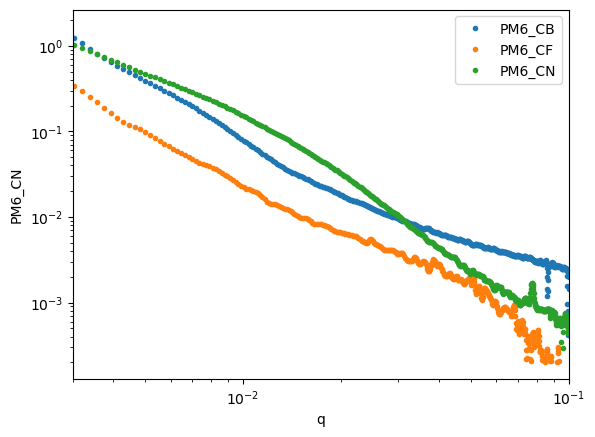

In [28]:
%matplotlib inline
plt.close('all')

# qmin = 0.008
qmin = None
# qmax = float(full_DS.q.max())
qmax = None

plt.close('all')
fig, ax = plt.subplots()
for sample in ['PM6_CB', 'PM6_CF', 'PM6_CN']:
# for sample in ['PM7_CB', 'PM7_CF', 'PM7_CN']:
# for sample in saxs_DS.data_vars:
    saxs_DS[sample].sel(q=slice(qmin,qmax)).plot.line(ax=ax, xscale='log',yscale='log', label=sample, linestyle='', marker='.')

# ax.set_ybound(lower=1e-4)
ax.set(xlim=(0.003,0.1))
# ax.set(xlim=(0.05,0.06))
# ax.xaxis.set_
ax.legend()
plt.show()

## Fit data

In [108]:
fibrilsPath = pathlib.Path('/Users/andrew/local_data_analysis/local_rsoxs/data')
fibril_paths = sorted(fibrilsPath.glob('dtot*'), key=lambda f: float(f.name.split('_')[0][6:]))
[f.name for f in fibril_paths]

['dtotal25_length2000_flex0p1_edens0p0001',
 'dtotal25_length2000_flex0p0001_edens0p0001',
 'dtotal50_length2000_flex0p0001_edens0p0001',
 'dtotal75_length2000_flex0p0001_edens0p0001',
 'dtotal100_length2000_flex0p0001_edens0p0001',
 'dtotal125_length2000_flex0p0001_edens0p0001',
 'dtotal150_length2000_flex0p0001_edens0p0001',
 'dtotal175_length2000_flex0p0001_edens0p0001',
 'dtotal200_length2000_flex0p0001_edens0p0001',
 'dtotal225_length2000_flex0p0001_edens0p0001',
 'dtotal250_length2000_flex0p0001_edens0p0001',
 'dtotal275_length2000_flex0p0001_edens0p0001',
 'dtotal300_length2000_flex0p0001_edens0p0001',
 'dtotal325_length2000_flex0p0001_edens0p0001',
 'dtotal350_length2000_flex0p0001_edens0p0001',
 'dtotal375_length2000_flex0p0001_edens0p0001',
 'dtotal400_length2000_flex0p0001_edens0p0001',
 'dtotal425_length2000_flex0p0001_edens0p0001',
 'dtotal450_length2000_flex0p0001_edens0p0001',
 'dtotal475_length2000_flex0p0001_edens0p0001',
 'dtotal500_length2000_flex0p0001_edens0p0001',

In [106]:
# saxs_DS['PM6_CF'].sel(q=slice(lower_bound,upper_bound)).dropna(dim='q').plot(xscale='log',yscale='log')

In [107]:
# plt.plot(fitting_q_vals,downsampled_exp_ints)
# plt.xscale('log')
# plt.yscale('log')
# plt.show()

In [109]:
# Desired criteria for folders
length = 2000  # Example value, replace as necessary
flexibility = "0p0001"  # Example value, replace as necessary
edens = '0p0001'

#skew bimodal
avg_diam1 = 480
scale1 = 175
shape1=5
weight1=0.00052
avg_diam2 = 110
scale2 = 120
shape2=0
weight2=0.01
avg_diam3 = 22
scale3 = 8
shape3=0

#lorentz peak
peak_center = 0.28
peak_scale = 6e-5
peak_width = 0.09

peak2_center = 0.25
peak2_scale = 3e-4
peak2_width = 0.6

# Filter the folders based on the naming convention

folders = fibril_paths.copy()

# Extract I vs Q data and diameters from folder names
q_values_list = []
intensities_list = []
diameters = []

for folder in folders:
    # Extracting the diameter from the folder name
    diameter = float(folder.name.split('_')[0][6:])
    diameters.append(diameter)
    
    filepath = folder.joinpath("flex_cylinder_num0_QI.txt")
    if filepath.exists():
        data = np.loadtxt(filepath)
        q_values, intensities = data[:, 0], data[:, 1]
        q_values_list.append(q_values)
        intensities_list.append(intensities)

# Compute the scattering intensity for the mixture (if any folders matched)
if q_values_list:
    mixture_intensity = compute_mixture_intensity_skewtrimodal(q_values_list[0], intensities_list, diameters, avg_diam1, scale1, 
                                                               shape1, weight1, avg_diam2, scale2, shape2, weight2, avg_diam3, scale3, shape3)
else:
    print("No matching folders found.")

### CF

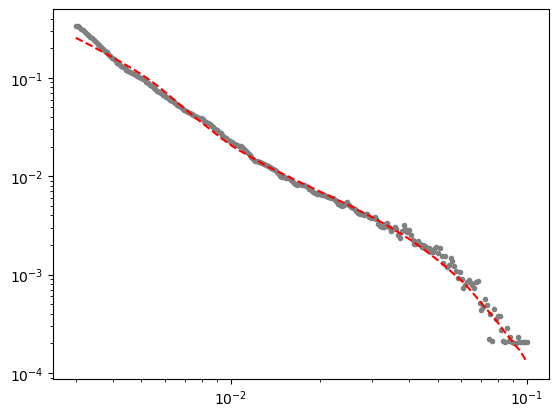

In [259]:
sample_name = 'PM6_CF'
load_prev_vals = False

# Select experimental data, interpolate to even logspace for fitting
lower_bound = 0.003
upper_bound = 0.1

sel_DA = saxs_DS[sample_name].sel(q=slice(lower_bound,upper_bound)).dropna(dim='q')


exp_q_values, exp_intensities = sel_DA.q.data, sel_DA.data

fitting_q_vals = np.logspace(np.log10(lower_bound), np.log10(upper_bound), 250)
downsampled_exp_ints = np.interp(fitting_q_vals, exp_q_values, exp_intensities)

# Create a model object
model = Model(trimodal_fit_function)

# Create a Parameters object and set initial values and constraints
q_vals = q_values_list[0]

# trimodal
# total_scale = ['total_scale', 1, 1e-10, 1000, True]
# avg_diam1 = ['avg_diam1', 100, 20, 800, True]
# sigma1 = ['sigma1', 1000, 25, 2000, True]
# shape1 = ['shape1', -0.3, -10, 20, True]
# weight1 = ['weight1', 0.0027, 1e-5, 0.005, True]
# avg_diam2 = ['avg_diam2', 25, 0, 300, True]
# sigma2 = ['sigma2', 203, 25, 300, True]
# shape2 = ['shape2', -2, -10, 20, True]
# weight2 = ['weight2', 0.32, 1e-3, 0.8, True]
# avg_diam3 = ['avg_diam3', 25, 0, 50, True]
# sigma3 = ['sigma3', 5, 1, 10, True]
# shape3 = ['shape3', 0, -10, 20, True]

total_scale = ['total_scale', 1, 1e-10, 1000, True]

avg_diam1 = ['avg_diam1', 25, 10, 50, True]
sigma1 = ['sigma1', 5, 1, 10, True]
shape1 = ['shape1', 0, -10, 20, True]
weight1 = ['weight1', 0.05, 1e-5, 0.15, True]

avg_diam2 = ['avg_diam2', 100, 20, 800, True]
sigma2 = ['sigma2', 50, 25, 200, True]
shape2 = ['shape2', -0.3, -10, 20, True]
weight2 = ['weight2', 0.32, 1e-3, 0.85, True]

avg_diam3 = ['avg_diam3', 500, 200, 800, True]
sigma3 = ['sigma3', 400, 25, 2000, True]
shape3 = ['shape3', -2, -10, 20, True]


variable_list = [total_scale, avg_diam1, sigma1, shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3]


if load_prev_vals:
    for var in variable_list:
        var[1] = result.params[var[0]].value
        var[2] = result.params[var[0]].min
        var[3] = result.params[var[0]].max
        var[4] = result.params[var[0]].vary

params = Parameters()

for var in variable_list:
    params.add(var[0], value=var[1], min=var[2], max=var[3], vary=var[4])

weights = 1/downsampled_exp_ints
# weights = 1 * downsampled_exp_ints

# # Perform the fit
result = model.fit(downsampled_exp_ints, params, q_vals=fitting_q_vals, weights=weights, method='leastsq', max_nfev=1000)
# result = model.fit(downsampled_exp_ints, params, weights=weights, method='leastsq', max_nfev=1000)

# Plot fit
fig, ax1 = plt.subplots()
ax1.plot(fitting_q_vals, downsampled_exp_ints, label='data', color='gray', linestyle='None', marker='.')
ax1.plot(fitting_q_vals, result.best_fit, label='fit', color = 'red', linestyle='--')
ax1.set_xscale('log')
ax1.set_yscale('log')

In [260]:
result

In [261]:
total_scale = result.params['total_scale'].value
avg_diam1 = result.params['avg_diam1'].value
sigma1 = result.params['sigma1'].value
shape1 = result.params['shape1'].value
weight1 = result.params['weight1'].value
avg_diam2 = result.params['avg_diam2'].value
sigma2 = result.params['sigma2'].value
shape2 = result.params['shape2'].value
weight2 = result.params['weight2'].value
avg_diam3 = result.params['avg_diam3' ].value
sigma3 = result.params['sigma3'].value
shape3 = result.params['shape3'].value

0.010220943120241377


/var/folders/m1/v62q73kx1ylgb2vpydrxbyy40000gn/T/ipykernel_7234/1672238625.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(x_labels, rotation=45)
/var/folders/m1/v62q73kx1ylgb2vpydrxbyy40000gn/T/ipykernel_7234/1672238625.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(x_labels, rotation=45)


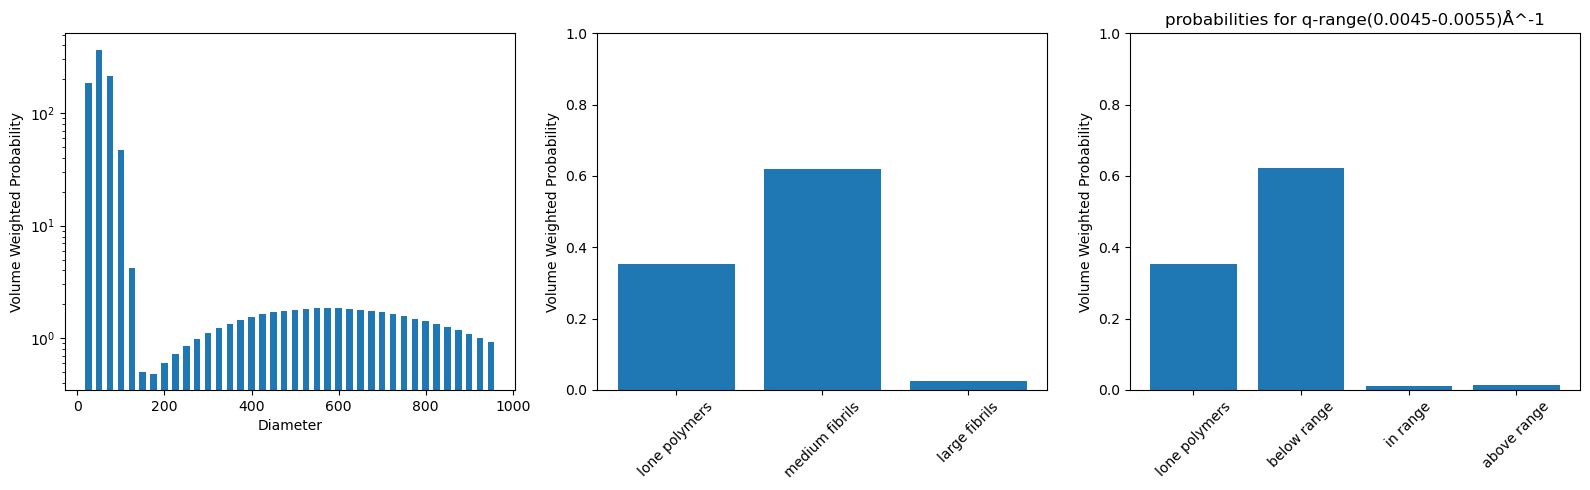

In [262]:
# Plot histogram of actual diameters
diameters = []

for folder in fibril_paths:
    # Extracting the diameter from the folder name
    diameter_str = folder.name.split('dtotal')[1].split('_length')[0]
    diameter = float(diameter_str)  # Convert to float
    diameters.append(diameter)

diameters = np.asarray(diameters)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figheight(5)
fig.set_figwidth(16)
fibril_weights = skew_trimodal(np.array(diameters), avg_diam1, sigma1, shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3)
fibril_weigths = fibril_weights
sum_weights = np.sum(fibril_weights)
fibril_weights = fibril_weights/sum_weights

# Plot bars for actual diameters with weights from the Schulz-Zimm distribution
ax1.bar(diameters, fibril_weights*np.pi*(diameters/2)**2, width=15, alpha=1, label="polymer/fibril diameters")

running_avg_mid = 0
running_avg_high = 0
single_polymers = 0
mid_diameters = 0
high_diameters = 0

for i, diam in enumerate(diameters):
    if diam == 25:
        single_polymers += fibril_weights[i]
    if ((diam>25) and (diam<501)):
        mid_diameters += fibril_weights[i]
        running_avg_mid += diam*fibril_weights[i]
    if diam>501:
        high_diameters += fibril_weights[i]
        running_avg_high += diam*fibril_weights[i]
        
mid_num_avg = running_avg_mid/mid_diameters
high_num_avg = running_avg_high/high_diameters

weights_area = []
for i, diam in enumerate(diameters):
    weight_area = fibril_weights[i]*np.pi*(diam/2)**2
    weights_area.append(weight_area)
weights_area = np.asarray(weights_area)
weights_area = weights_area/np.sum(weights_area)

running_avg_mid = 0
running_avg_high = 0
single_polymers = 0
mid_diameters = 0
high_diameters = 0

for i, diam in enumerate(diameters):
    if diam == 25:
        single_polymers += weights_area[i]
    if ((diam>25) and (diam<501)):
        mid_diameters += weights_area[i]
        running_avg_mid += diam*weights_area[i]
    if diam>501:
        high_diameters += weights_area[i]
        running_avg_high += diam*weights_area[i]

mid_vol_avg = running_avg_mid/mid_diameters
high_vol_avg = running_avg_high/high_diameters


ax1.set_yscale('log')
# ax1.set_ylim(1e-5,2)
ax1.set_xlabel('Diameter')
ax1.set_ylabel('Volume Weighted Probability')
ax1.set_title('')
# plt.legend(loc='upper right', frameon=False)
# plt.show()
weights_data = np.column_stack((diameters, fibril_weights))
# np.savetxt(save_dir + gen_file_name + '_distribution_num_weights.txt', weights_data)


x_labels = [f'lone polymers', f'medium fibrils', f'large fibrils']
height_values = [single_polymers, mid_diameters, high_diameters]

# Plot bars for actual diameters with weights from the Schulz-Zimm distribution
ax2.bar(x_labels, height_values)
ax2.set_ylabel('Volume Weighted Probability')
ax2.set_ylim(0,1)
ax2.set_title('')
ax2.set_xticklabels(x_labels, rotation=45)

single_polymers = 0
low_diameters = 0
mid_diameters = 0
high_diameters = 0

for i, diam in enumerate(diameters):
    if diam == 25:
        single_polymers += weights_area[i]
    if ((diam>25) and (diam<575)):
        low_diameters += weights_area[i]
    if ((diam>=575) and (diam<=700)):
        mid_diameters += weights_area[i]
    if diam>700:
        high_diameters += weights_area[i]

x_labels = ['lone polymers','below range', 'in range', 'above range']
height_values = [single_polymers, low_diameters, mid_diameters, high_diameters]

# Plot bars for actual diameters with weights from the Schulz-Zimm distribution
ax3.bar(x_labels, height_values)
ax3.set_ylabel('Volume Weighted Probability')
ax3.set_ylim(0,1)
ax3.set_title('probabilities for q-range(0.0045-0.0055)Å^-1')
ax3.set_xticklabels(x_labels, rotation=45)

print(mid_diameters)
plt.tight_layout()
plt.show()

### CN

In [306]:
shape3

-12.435400427843184

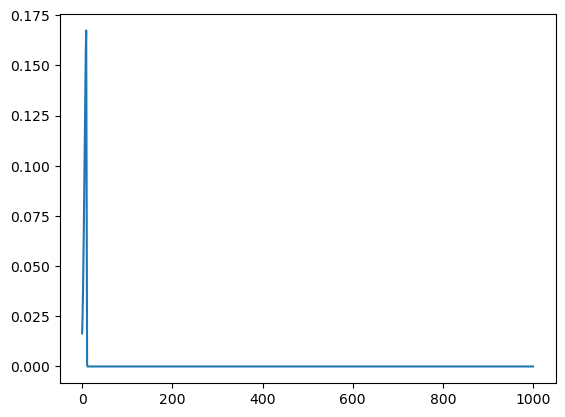

In [356]:
%matplotlib inline
plt.close('all')
x=np.linspace(0,1000,1000)
plt.plot(x, skewnorm.pdf(x, a=shape1, loc=avg_diam1, scale=sigma1))
# plt.plot(x, skewnorm.pdf(x, a=shape2, loc=avg_diam2, scale=sigma2))
# plt.plot(x, skewnorm.pdf(x, a=shape3, loc=avg_diam3, scale=sigma3))
# plt.plot(x, skewnorm.pdf(x, a=-4, loc=avg_diam3, scale=100))
plt.yscale('linear')
plt.show()

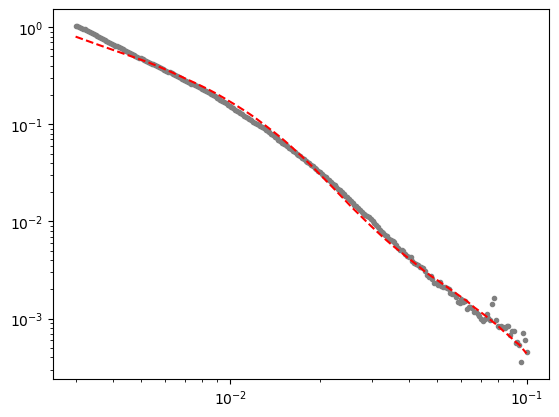

In [344]:
sample_name = 'PM6_CN'
load_prev_vals = False

# Select experimental data, interpolate to even logspace for fitting
lower_bound = 0.003
upper_bound = 0.1

sel_DA = saxs_DS[sample_name].sel(q=slice(lower_bound,upper_bound)).dropna(dim='q')


exp_q_values, exp_intensities = sel_DA.q.data, sel_DA.data

fitting_q_vals = np.logspace(np.log10(lower_bound), np.log10(upper_bound), 250)
downsampled_exp_ints = np.interp(fitting_q_vals, exp_q_values, exp_intensities)

# Create a model object
model = Model(trimodal_fit_function)

# Create a Parameters object and set initial values and constraints
q_vals = q_values_list[0]

# trimodal
# total_scale = ['total_scale', 1, 1e-10, 1000, True]
# avg_diam1 = ['avg_diam1', 100, 20, 800, True]
# sigma1 = ['sigma1', 1000, 25, 2000, True]
# shape1 = ['shape1', -0.3, -10, 20, True]
# weight1 = ['weight1', 0.0027, 1e-5, 0.005, True]
# avg_diam2 = ['avg_diam2', 25, 0, 300, True]
# sigma2 = ['sigma2', 203, 25, 300, True]
# shape2 = ['shape2', -2, -10, 20, True]
# weight2 = ['weight2', 0.32, 1e-3, 0.8, True]
# avg_diam3 = ['avg_diam3', 25, 0, 50, True]
# sigma3 = ['sigma3', 5, 1, 10, True]
# shape3 = ['shape3', 0, -10, 20, True]

total_scale = ['total_scale', 1, 1e-15, 1000, True]

avg_diam1 = ['avg_diam1', 25, 10, 50, True]
sigma1 = ['sigma1', 5, 1, 10, True]
shape1 = ['shape1', 0, -20, 20, True]
weight1 = ['weight1', 0.05, 1e-5, 0.12, True]

avg_diam2 = ['avg_diam2', 100, 20, 800, True]
sigma2 = ['sigma2', 50, 25, 200, True]
shape2 = ['shape2', 0, -20, 20, True]
weight2 = ['weight2', 0.8, 1e-3, 0.82, True]

avg_diam3 = ['avg_diam3', 200, 100, 800, True]
sigma3 = ['sigma3', 700, 25, 2000, True]
shape3 = ['shape3', -8, -20, 20, True]

variable_list = [total_scale, avg_diam1, sigma1, shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3]


if load_prev_vals:
    for var in variable_list:
        var[1] = result.params[var[0]].value
        var[2] = result.params[var[0]].min
        var[3] = result.params[var[0]].max
        var[4] = result.params[var[0]].vary

params = Parameters()

for var in variable_list:
    params.add(var[0], value=var[1], min=var[2], max=var[3], vary=var[4])

weights = 1/downsampled_exp_ints

# # Perform the fit
result = model.fit(downsampled_exp_ints, params, q_vals=fitting_q_vals, weights=weights, method='leastsq', max_nfev=1000)
# result = model.fit(downsampled_exp_ints, params, weights=weights, method='leastsq', max_nfev=1000)

# Plot fit
fig, ax1 = plt.subplots()
ax1.plot(fitting_q_vals, downsampled_exp_ints, label='data', color='gray', linestyle='None', marker='.')
ax1.plot(fitting_q_vals, result.best_fit, label='fit', color = 'red', linestyle='--')
ax1.set_xscale('log')
ax1.set_yscale('log')

In [345]:
result

In [346]:
total_scale = result.params['total_scale'].value
avg_diam1 = result.params['avg_diam1'].value
sigma1 = result.params['sigma1'].value
shape1 = result.params['shape1'].value
weight1 = result.params['weight1'].value
avg_diam2 = result.params['avg_diam2'].value
sigma2 = result.params['sigma2'].value
shape2 = result.params['shape2'].value
weight2 = result.params['weight2'].value
avg_diam3 = result.params['avg_diam3' ].value
sigma3 = result.params['sigma3'].value
shape3 = result.params['shape3'].value

5.5608882840667704e-05


/var/folders/m1/v62q73kx1ylgb2vpydrxbyy40000gn/T/ipykernel_7234/354003539.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(x_labels, rotation=45)
/var/folders/m1/v62q73kx1ylgb2vpydrxbyy40000gn/T/ipykernel_7234/354003539.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(x_labels, rotation=45)


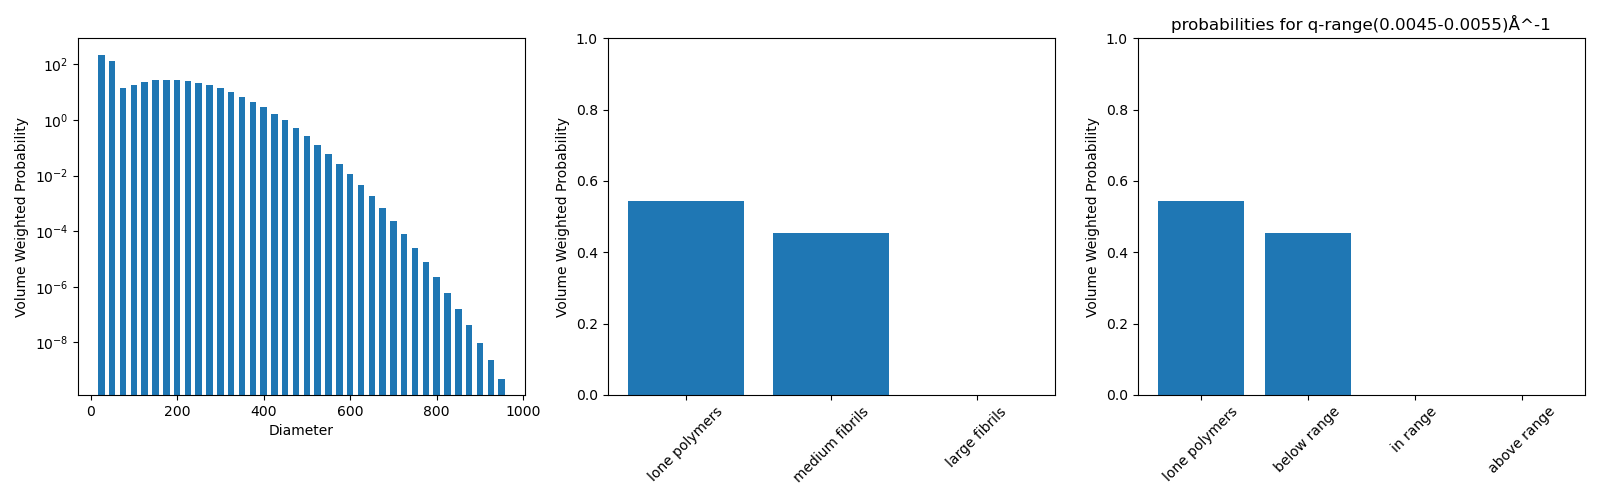

In [364]:
%matplotlib ipympl
plt.close('all')

# Plot histogram of actual diameters
diameters = []

for folder in fibril_paths:
    # Extracting the diameter from the folder name
    diameter_str = folder.name.split('dtotal')[1].split('_length')[0]
    diameter = float(diameter_str)  # Convert to float
    diameters.append(diameter)

diameters = np.asarray(diameters)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figheight(5)
fig.set_figwidth(16)
fibril_weights = skew_trimodal(np.array(diameters), avg_diam1, sigma1, shape1, weight1, avg_diam2, sigma2, shape2, weight2, avg_diam3, sigma3, shape3)
fibril_weigths = fibril_weights
sum_weights = np.sum(fibril_weights)
fibril_weights = fibril_weights/sum_weights

# Plot bars for actual diameters with weights from the Schulz-Zimm distribution
ax1.bar(diameters, fibril_weights*np.pi*(diameters/2)**2, width=15, alpha=1, label="polymer/fibril diameters")
# ax1.bar(diameters, 1*np.pi*(diameters/2)**2, width=15, alpha=1, label="polymer/fibril diameters")

running_avg_mid = 0
running_avg_high = 0
single_polymers = 0
mid_diameters = 0
high_diameters = 0

for i, diam in enumerate(diameters):
    if diam == 25:
        single_polymers += fibril_weights[i]
    if ((diam>25) and (diam<501)):
        mid_diameters += fibril_weights[i]
        running_avg_mid += diam*fibril_weights[i]
    if diam>501:
        high_diameters += fibril_weights[i]
        running_avg_high += diam*fibril_weights[i]
        
mid_num_avg = running_avg_mid/mid_diameters
high_num_avg = running_avg_high/high_diameters

weights_area = []
for i, diam in enumerate(diameters):
    weight_area = fibril_weights[i]*np.pi*(diam/2)**2
    weights_area.append(weight_area)
weights_area = np.asarray(weights_area)
weights_area = weights_area/np.sum(weights_area)

running_avg_mid = 0
running_avg_high = 0
single_polymers = 0
mid_diameters = 0
high_diameters = 0

for i, diam in enumerate(diameters):
    if diam == 25:
        single_polymers += weights_area[i]
    if ((diam>25) and (diam<501)):
        mid_diameters += weights_area[i]
        running_avg_mid += diam*weights_area[i]
    if diam>501:
        high_diameters += weights_area[i]
        running_avg_high += diam*weights_area[i]

mid_vol_avg = running_avg_mid/mid_diameters
high_vol_avg = running_avg_high/high_diameters


ax1.set_yscale('log')
# ax1.set_ylim(1e-5,2)
ax1.set_xlabel('Diameter')
ax1.set_ylabel('Volume Weighted Probability')
ax1.set_title('')
# plt.legend(loc='upper right', frameon=False)
# plt.show()
weights_data = np.column_stack((diameters, fibril_weights))
# np.savetxt(save_dir + gen_file_name + '_distribution_num_weights.txt', weights_data)


x_labels = [f'lone polymers', f'medium fibrils', f'large fibrils']
height_values = [single_polymers, mid_diameters, high_diameters]

# Plot bars for actual diameters with weights from the Schulz-Zimm distribution
ax2.bar(x_labels, height_values)
ax2.set_ylabel('Volume Weighted Probability')
ax2.set_ylim(0,1)
ax2.set_title('')
ax2.set_xticklabels(x_labels, rotation=45)

single_polymers = 0
low_diameters = 0
mid_diameters = 0
high_diameters = 0

for i, diam in enumerate(diameters):
    if diam == 25:
        single_polymers += weights_area[i]
    if ((diam>25) and (diam<575)):
        low_diameters += weights_area[i]
    if ((diam>=575) and (diam<=700)):
        mid_diameters += weights_area[i]
    if diam>700:
        high_diameters += weights_area[i]

x_labels = ['lone polymers','below range', 'in range', 'above range']
height_values = [single_polymers, low_diameters, mid_diameters, high_diameters]

# Plot bars for actual diameters with weights from the Schulz-Zimm distribution
ax3.bar(x_labels, height_values)
ax3.set_ylabel('Volume Weighted Probability')
ax3.set_ylim(0,1)
ax3.set_title('probabilities for q-range(0.0045-0.0055)Å^-1')
ax3.set_xticklabels(x_labels, rotation=45)

print(mid_diameters)
plt.tight_layout()
plt.show()

In [362]:
fibril_weights*np.pi*(diameters/2)**2

array([2.25638494e+02, 2.25638494e+02, 1.33450660e+02, 1.40554285e+01,
       1.76192315e+01, 2.28751848e+01, 2.65268038e+01, 2.81272020e+01,
       2.76425443e+01, 2.53913696e+01, 2.19196196e+01, 1.78501008e+01,
       1.37483745e+01, 1.00344258e+01, 6.94989728e+00, 4.57272053e+00,
       2.86049546e+00, 1.70239808e+00, 9.64406405e-01, 5.20260672e-01,
       2.67358359e-01, 1.30919022e-01, 6.11015486e-02, 2.71850684e-02,
       1.15322166e-02, 4.66513525e-03, 1.79986994e-03, 6.62357836e-04,
       2.32521007e-04, 7.78731897e-05, 2.48830740e-05, 7.58648886e-06,
       2.20711855e-06, 6.12749785e-07, 1.62343773e-07, 4.10490697e-08,
       9.90614488e-09, 2.28168973e-09, 5.01619644e-10])